# JAX LDS vs. NumPy LDS — apples-to-apples comparison

Compare `pillow_lab_rotation.lds.LinearDynamicalSystem` (NumPy) and
`pillow_lab_rotation.jax_lds_functional.LinearDynamicalSystemJAX` for:

1. E-step: filter outputs (means, covs, LL)
2. E-step: smoother outputs
3. Single M-step update from identical sufficient stats
4. Full EM: LL trajectory and final-iteration params
5. Aligned param recovery (same protocol as `lds_param_recovery.ipynb`)
6. With inputs (B + D=0)
7. Wall-clock timing

In [ ]:
from jax import config
config.update('jax_enable_x64', True)  # match numpy float64 for tight tolerances

import time
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from importlib import reload

from pillow_lab_rotation import lds as lds_np
from pillow_lab_rotation import lds_jax as lds_jx
from pillow_lab_rotation.simulate import LDSSim, generate_gaussian_inputs

plt.style.use('../JS.mplstyle')

## Helpers

In [2]:
def set_params_np(model, params):
    A, C, Q, Q0, mu0, R, *rest = params
    model.A, model.C = A.copy(), C.copy()
    model.Q, model.Q0 = Q.copy(), Q0.copy()
    model.mu0, model.R = mu0.copy(), R.copy()
    if rest:
        model.B = rest[0].copy()
    return model

def set_params_jx(model, params):
    A, C, Q, Q0, mu0, R, *rest = params
    model.A, model.C = jnp.asarray(A), jnp.asarray(C)
    model.Q, model.Q0 = jnp.asarray(Q), jnp.asarray(Q0)
    model.mu0, model.R = jnp.asarray(mu0), jnp.asarray(R)
    if rest:
        model.B = jnp.asarray(rest[0])
    return model

def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))

def report(name, np_arr, jx_arr):
    err = maxabs(np_arr, jx_arr)
    print(f'  {name:<14s} max|np-jx| = {err:.3e}')
    return err

## Generate ground-truth model + data

In [13]:
xdim, ydim = 4, 8
T = 100
n_trials = 200

sim = LDSSim(xdim, ydim)
np.random.seed(42)
sim.create_params()
true_params = sim.get_params()  # (A, C, Q, Q0, mu0, R)

_, Y = sim.simulate(T, n_trials)
Y_jx = jnp.asarray(Y)
Y.shape

(200, 100, 8, 1)

## 1. Filter outputs match

In [ ]:
m_np = lds_np.LinearDynamicalSystem(xdim, ydim)
m_jx = lds_jx.LinearDynamicalSystemJAX(xdim, ydim)
set_params_np(m_np, true_params)
set_params_jx(m_jx, true_params)

# numpy: fit() needs to be called for run_filter to work; instead invoke run_filter directly.
m_np.observations = Y
m_np.n_trials, m_np.T = n_trials, T
m_np.inputs = np.zeros((n_trials, T, 0, 1))
m_np.run_filter()

m_jx.observations = Y_jx
m_jx.n_trials, m_jx.T = n_trials, T
m_jx.inputs = jnp.zeros((n_trials, T, 0, 1))
m_jx.run_filter()

print('Filter:')
report('x_predicted', m_np.x_predicted, m_jx.x_predicted)
report('x_filtered',  m_np.x_filtered,  m_jx.x_filtered)
report('P_predicted', m_np.P_predicted, m_jx.P_predicted)
report('P_filtered',  m_np.P_filtered,  m_jx.P_filtered)
report('LL',          m_np.LL,          m_jx.LL)

Filter:
  x_predicted    max|np-jx| = 2.487e-14
  x_filtered     max|np-jx| = 2.842e-14
  P_predicted    max|np-jx| = 1.421e-14
  P_filtered     max|np-jx| = 1.776e-14
  LL             max|np-jx| = 0.000e+00


0.0

## 2. Smoother outputs match

In [15]:
m_np.run_smoother()
m_jx.run_smoother()

print('Smoother:')
report('m',       m_np.m,       m_jx.m)
report('sigma',   m_np.sigma,   m_jx.sigma)
report('sigma_x', m_np.sigma_x, m_jx.sigma_x)

Smoother:
  m              max|np-jx| = 3.553e-14
  sigma          max|np-jx| = 1.643e-14
  sigma_x        max|np-jx| = 1.010e-14


1.0096090630185017e-14

## 3. Single M-step from identical sufficient stats

In [ ]:
m_np._get_sufficient_stats()
m_jx._get_sufficient_stats()

print('Sufficient stats:')
for name in ['M11', 'M2T', 'M1Tm1', 'M1T', 'M_delta', 'Y', 'Y_hat']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

m_np.m_step(); m_jx.m_step()

print('\nUpdated params:')
for name in ['A', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

Sufficient stats:
  M11            max|np-jx| = 5.684e-13
  M2T            max|np-jx| = 9.313e-10
  M1Tm1          max|np-jx| = 9.313e-10
  M1T            max|np-jx| = 9.313e-10
  M_delta        max|np-jx| = 9.313e-10
  Y              max|np-jx| = 7.451e-09
  Y_hat          max|np-jx| = 1.397e-09

Updated params:
  A              max|np-jx| = 3.664e-15
  C              max|np-jx| = 7.050e-15
  Q              max|np-jx| = 1.176e-13
  Q0             max|np-jx| = 2.220e-15
  mu0            max|np-jx| = 1.110e-15
  R              max|np-jx| = 3.725e-13


## 4. Full EM: LL curve and final params

LL trajectory max|np-jx| = 2.132e-14
Final iter LL np = -16.916526, jx = -16.916526

Final params:
  A              max|np-jx| = 1.027e-13
  C              max|np-jx| = 4.269e-13
  Q              max|np-jx| = 1.787e-12
  Q0             max|np-jx| = 1.778e-12
  mu0            max|np-jx| = 7.909e-13
  R              max|np-jx| = 9.313e-12


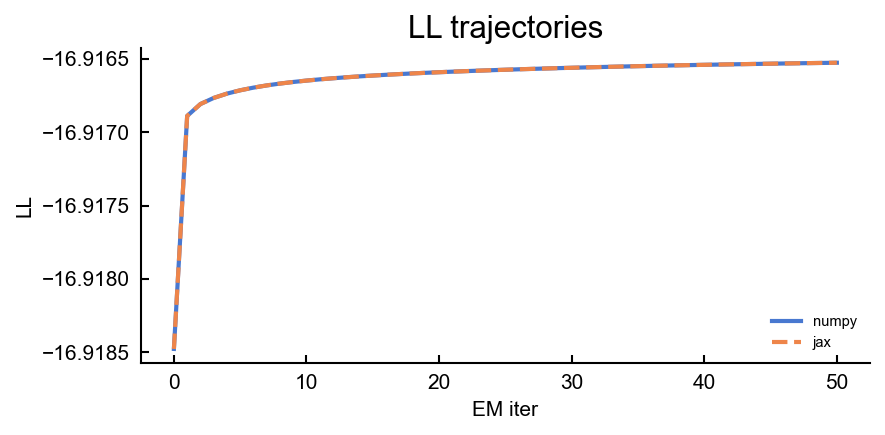

In [17]:
max_iter = 50

m_np = lds_np.LinearDynamicalSystem(xdim, ydim)
m_jx = lds_jx.LinearDynamicalSystemJAX(xdim, ydim)
set_params_np(m_np, true_params)
set_params_jx(m_jx, true_params)

m_np.fit(Y, max_iter=max_iter)
m_jx.fit(Y_jx, max_iter=max_iter)

ll_np = np.array(m_np.ll_history)
ll_jx = np.array(m_jx.ll_history)
print(f'LL trajectory max|np-jx| = {np.max(np.abs(ll_np - ll_jx)):.3e}')
print(f'Final iter LL np = {ll_np[-1]:.6f}, jx = {ll_jx[-1]:.6f}')

print('\nFinal params:')
for name in ['A', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ll_np, label='numpy', lw=2)
ax.plot(ll_jx, label='jax', ls='--', lw=2)
ax.set_xlabel('EM iter'); ax.set_ylabel('LL')
ax.set_title('LL trajectories'); ax.legend()
plt.show()

## 5. Aligned param recovery (both implementations on the same trial counts)

Same protocol as `lds_param_recovery.ipynb`: init both at the true params, fit, then align via $H = (C'^T C')^{-1} C'^T C_{true}$ and compare aligned MSEs.

In [18]:
xdim_r, ydim_r = 5, 10
T_r = 50
trial_list = [50, 100, 200, 500, 1000, 2000, 5000]

sim_r = LDSSim(xdim_r, ydim_r)
np.random.seed(42)
sim_r.create_params()
A_t, C_t, Q_t, Q0_t, mu0_t, R_t = sim_r.get_params()
_, Y_r = sim_r.simulate(T_r, trial_list[-1])
Y_r_jx = jnp.asarray(Y_r)

def fit_one(model_factory, set_fn, Y_data, n):
    model = model_factory()
    set_fn(model, (A_t, C_t, Q_t, Q0_t, mu0_t, R_t))
    model.fit(Y_data[:n], max_iter=50)
    return model

def aligned_losses(model):
    A, C, Q, R = (np.asarray(model.A), np.asarray(model.C),
                  np.asarray(model.Q), np.asarray(model.R))
    H = np.linalg.inv(C.T @ C) @ C.T @ C_t
    H_inv = np.linalg.inv(H)
    return {
        'A': np.mean((H_inv @ A @ H - A_t)**2),
        'C': np.mean((C @ H - C_t)**2),
        'Q': np.mean((H_inv @ Q @ H_inv.T - Q_t)**2),
        'R': np.mean((R - R_t)**2),
    }

results = {'np': {k: [] for k in 'ACQR'},
           'jx': {k: [] for k in 'ACQR'}}
for n in trial_list:
    print(f'n_trials = {n}')
    mn = fit_one(lambda: lds_np.LinearDynamicalSystem(xdim_r, ydim_r), set_params_np, Y_r,    n)
    mj = fit_one(lambda: lds_jx.LinearDynamicalSystemJAX(xdim_r, ydim_r), set_params_jx, Y_r_jx, n)
    for k, v in aligned_losses(mn).items(): results['np'][k].append(v)
    for k, v in aligned_losses(mj).items(): results['jx'][k].append(v)

n_trials = 50
n_trials = 100
n_trials = 200
n_trials = 500
n_trials = 1000
n_trials = 2000
n_trials = 5000


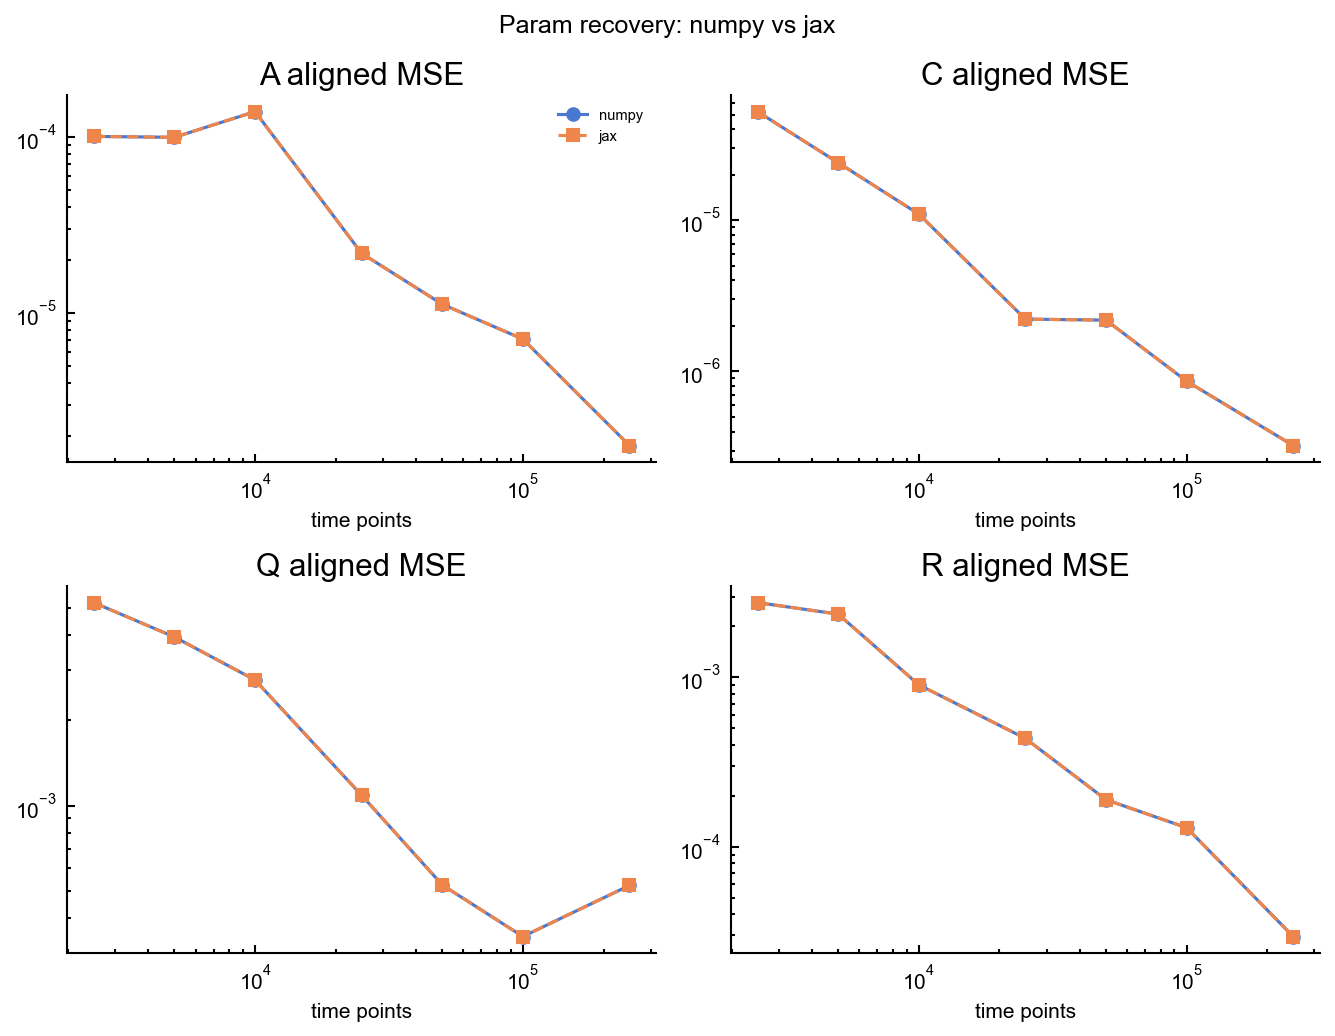

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
x_axis = T_r * np.array(trial_list)
for ax, name in zip(axes.flat, ['A', 'C', 'Q', 'R']):
    ax.plot(x_axis, results['np'][name], 'o-', label='numpy')
    ax.plot(x_axis, results['jx'][name], 's--', label='jax')
    ax.set_title(f'{name} aligned MSE')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('time points')
axes[0, 0].legend()
fig.suptitle('Param recovery: numpy vs jax')
fig.tight_layout()
plt.show()

## 6. With inputs (B, no feedthrough)

In [20]:
udim = 3
sim_u = LDSSim(xdim, ydim, udim=udim, feedthrough=False)
np.random.seed(7)
sim_u.create_params()
params_u = sim_u.get_params()  # (A, C, Q, Q0, mu0, R, B)
U_full = generate_gaussian_inputs(n_trials, T, udim)
_, Y_u = sim_u.simulate(T, n_trials, inputs=U_full)
U_jx = jnp.asarray(U_full)
Y_u_jx = jnp.asarray(Y_u)

m_np = lds_np.LinearDynamicalSystem(xdim, ydim, udim=udim, feedthrough=False)
m_jx = lds_jx.LinearDynamicalSystemJAX(xdim, ydim, udim=udim, feedthrough=False)
set_params_np(m_np, params_u)
set_params_jx(m_jx, params_u)

m_np.fit(Y_u, inputs=U_full, max_iter=30)
m_jx.fit(Y_u_jx, inputs=U_jx, max_iter=30)

ll_np_u = np.array(m_np.ll_history)
ll_jx_u = np.array(m_jx.ll_history)
print(f'LL trajectory max|np-jx| = {np.max(np.abs(ll_np_u - ll_jx_u)):.3e}')

print('\nFinal params (with inputs):')
for name in ['A', 'B', 'C', 'Q', 'Q0', 'mu0', 'R']:
    report(name, getattr(m_np, name), getattr(m_jx, name))

LL trajectory max|np-jx| = 2.842e-14

Final params (with inputs):
  A              max|np-jx| = 1.061e-13
  B              max|np-jx| = 1.060e-13
  C              max|np-jx| = 1.807e-13
  Q              max|np-jx| = 4.833e-12
  Q0             max|np-jx| = 2.081e-12
  mu0            max|np-jx| = 1.923e-13
  R              max|np-jx| = 2.757e-11


## 7. Wall-clock timing

JIT compile is excluded from the JAX timing — the fit is run once for compile, then a second fit is timed.

In [21]:
n_iter_time = 30

# numpy
m_np = lds_np.LinearDynamicalSystem(xdim, ydim)
set_params_np(m_np, true_params)
t0 = time.perf_counter()
m_np.fit(Y, max_iter=n_iter_time)
t_np = time.perf_counter() - t0

# jax: warm-up compile, then time
m_jx = lds_jx.LinearDynamicalSystemJAX(xdim, ydim)
set_params_jx(m_jx, true_params)
m_jx.fit(Y_jx, max_iter=2)  # compile
set_params_jx(m_jx, true_params)
t0 = time.perf_counter()
m_jx.fit(Y_jx, max_iter=n_iter_time)
_ = m_jx.LL.block_until_ready()
t_jx = time.perf_counter() - t0

print(f'numpy: {t_np:.3f}s  ({t_np/n_iter_time*1e3:.2f} ms/iter)')
print(f'jax:   {t_jx:.3f}s  ({t_jx/n_iter_time*1e3:.2f} ms/iter)')
print(f'speedup: {t_np/t_jx:.1f}x')

numpy: 0.332s  (11.07 ms/iter)
jax:   0.179s  (5.96 ms/iter)
speedup: 1.9x
